<a href="https://colab.research.google.com/github/MatchLab-Imperial/deep-learning-course/blob/master/08_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Reinforcement Learning: DQN and Actor–Critic

Part 1 represented action values in a table. That works when the state space is small and discrete, but not when observations are continuous or high-dimensional. This notebook develops two ways to scale reinforcement learning with neural networks:

1. **Deep Q-Network (DQN):** approximate $Q(s,a)$ and choose the action with the largest predicted value.
2. **Actor–Critic:** learn a policy (the actor) and a value estimate (the critic) together.

We begin with DQN because it is the direct neural extension of tabular Q-learning. The Actor–Critic section then shows a different approach: learning the policy itself.

In [ ]:
# Enter your CID below before running the submission cells.
CID = "00000000"

In [ ]:
from pathlib import Path

SUBMISSION_DIR = Path("./submission")
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

def submission_path(suffix):
    """Return a CID-prefixed path inside the submission folder."""
    student_cid = CID.strip()
    if not student_cid or student_cid == "YOUR_CID":
        raise ValueError("Enter your CID in the CID cell before saving coursework.")
    return SUBMISSION_DIR / f"{student_cid}_{suffix}"


def save_current_cell_code(suffix, start_marker=None, end_marker=None):
    """Save the student-authored part of the currently executing notebook cell."""
    shell = get_ipython()
    source = ""

    if shell is not None and hasattr(shell, "get_parent"):
        try:
            source = shell.get_parent().get("content", {}).get("code", "")
        except Exception:
            source = ""

    if not source and shell is not None:
        history = getattr(getattr(shell, "history_manager", None),
                          "input_hist_raw", [])
        if history:
            source = history[-1]

    if not source:
        raise RuntimeError("Could not read the current notebook cell for submission.")

    if start_marker is not None:
        start = source.find(start_marker)
        if start < 0:
            raise ValueError(f"Start marker not found: {start_marker}")
        source = source[start:]

    if end_marker is not None:
        end = source.find(end_marker)
        if end >= 0:
            source = source[:end]

    output_path = submission_path(suffix)
    output_path.write_text(source.rstrip() + "\n", encoding="utf-8")
    print(f"Saved: {output_path}")
    return output_path


print(f"Coursework files will be saved in: {SUBMISSION_DIR.resolve()}")


In [1]:
!pip install gymnasium --upgrade

import base64
import collections
import glob
import io
import os
import random
import time
import torch

from IPython import display as ipythondisplay
from IPython.display import HTML
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

def set_seed(seed: int) -> None:
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

zsh:1: /Volumes/WDSN5000/Users/d1meac/Documents/DeepLearningNotebooks/venv/bin/pip: bad interpreter: /Volumes/Lenovo/Users/dev/Documents/deep-learning-course/venv/bin/python3.11: no such file or directory


# Deep Q-Networks (DQN)

## From a Q-table to a neural function approximator

Tabular Q-learning stores one number for every state-action pair. CartPole instead describes a state with four continuous values: cart position, cart velocity, pole angle, and pole angular velocity. Even after coarse discretisation, a table would be large and would not naturally generalise between nearby states.

A **Deep Q-Network** replaces the table with a neural network $Q_\theta(s,a)$. For a state vector $s$, the network produces one value per discrete action:

$$
Q_\theta(s,\cdot)
=
\begin{bmatrix}
Q_\theta(s,\text{left}) & Q_\theta(s,\text{right})
\end{bmatrix}.
$$

These outputs are **action values, not probabilities**. They estimate the discounted return expected after taking each action and then behaving greedily. The agent exploits its current knowledge with

$$a^*=\arg\max_a Q_\theta(s,a).$$

Because the same network is evaluated for nearby observations, learning from one transition can improve predictions for many similar states. This generalisation is the key advantage over a Q-table.

## The Bellman target: turning experience into a supervised-learning signal

Each interaction produces a transition $(s,a,r,s',d)$, where $d$ records whether the episode ended. DQN constructs a one-step target for the action that was actually taken:

$$
y =
\begin{cases}
r, & \text{if the transition is terminal},\\
r + \gamma \max_{a'} Q_\theta(s',a'), & \text{otherwise}.
\end{cases}
$$

It then minimises the temporal-difference loss

$$L(\theta)=\left(Q_\theta(s,a)-y\right)^2.$$

The target contains the network's own estimate of future return, so DQN is a **bootstrapping** method. It is also **off-policy**: behaviour may include exploratory actions, while the target assumes the greedy action at the next state.

For CartPole, the environment gives $+1$ for every step the pole remains balanced. A larger predicted Q-value therefore means that the corresponding action is expected to keep the episode alive for longer.

## Exploration and experience replay

DQN repeats the following interaction-and-learning cycle:

<table align="center" style="width:80%; max-width:520px; border-collapse:separate; border-spacing:0; margin:20px auto;">
  <tr><td align="center" style="padding:16px; border:2px solid #4C78A8; border-radius:10px; background:#EEF5FC; color:#000000;"><b>1. Select an action</b><br><small style="color:#000000;">Observe state <i>s</i>. With probability ε choose a random action; otherwise choose the action with the largest predicted Q-value.</small></td></tr>
  <tr><td align="center" style="padding:2px; border:none; font-size:28px; line-height:1.2; color:#4C78A8;">↓</td></tr>
  <tr><td align="center" style="padding:16px; border:2px solid #59A14F; border-radius:10px; background:#F0F8EF; color:#000000;"><b>2. Interact and remember</b><br><small style="color:#000000;">Execute the action, observe reward <i>r</i>, next state <i>s′</i>, and the termination flag <i>d</i>, then store the transition (<i>s, a, r, s′, d</i>) in replay memory.</small></td></tr>
  <tr><td align="center" style="padding:2px; border:none; font-size:28px; line-height:1.2; color:#4C78A8;">↓</td></tr>
  <tr><td align="center" style="padding:16px; border:2px solid #F28E2B; border-radius:10px; background:#FFF5E8; color:#000000;"><b>3. Sample a replay mini-batch</b><br><small style="color:#000000;">Uniformly sample past transitions. Mixing experiences from different episodes reduces temporal correlation and allows each transition to be reused.</small></td></tr>
  <tr><td align="center" style="padding:2px; border:none; font-size:28px; line-height:1.2; color:#4C78A8;">↓</td></tr>
  <tr><td align="center" style="padding:16px; border:2px solid #B07AA1; border-radius:10px; background:#F8F0F7; color:#000000;"><b>4. Update the Q-network</b><br><small style="color:#000000;">Build terminal-aware Bellman targets, minimise the Q-value prediction loss, decay ε, and repeat the cycle from the next state or a reset environment.</small></td></tr>
</table>

> **Exploration** determines which experience is collected; **replay** determines which stored experience is used for a gradient update.

Training starts with a large $\epsilon$ so the agent encounters varied situations, then gradually decays it to favour exploitation. The implementation below uses one online network and detaches the Bellman target with `torch.no_grad()`. Standard DQN usually adds a second **target network**, copied from the online network periodically so the target changes more slowly. Replay memory and a target network address different sources of instability: correlated data and moving targets, respectively.

## The DQN agent

The agent connects each idea above to one method:

- `_build_model` creates a network with four CartPole inputs and two action-value outputs.
- `act` implements $\epsilon$-greedy behaviour during training.
- `remember` appends $(s,a,r,s',d)$ to the replay buffer.
- `replay` samples a mini-batch, builds terminal-aware Bellman targets, and updates only the Q-value of each selected action.
- `exploit` always chooses the greedy action for evaluation.

Notice that the final layer has no softmax. Q-values are unrestricted return estimates, so normalising them as probabilities would change their meaning.

In [2]:
class DQNAgent:
    def __init__(self, state_size, action_size, device=None):
        self.state_size   = state_size
        self.action_size  = action_size
        self.memory       = collections.deque(maxlen=2000)
        self.gamma        = 0.95       # discount rate
        self.epsilon      = 1.0        # exploration rate
        self.epsilon_min  = 0.01
        self.epsilon_decay= 0.995
        self.learning_rate= 0.001

        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model  = self._build_model().to(self.device)
        self.opt    = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.loss_fn= nn.MSELoss()

    def _build_model(self):
        # 2×24 MLP
        model = nn.Sequential(
            nn.Linear(self.state_size, 24),
            nn.ReLU(),
            nn.Linear(24, 24),
            nn.ReLU(),
            nn.Linear(24, self.action_size)  # Q(s, ·) action values (no activation)
        )
        return model

    # ---- replay buffer ----
    def remember(self, state, action, reward, next_state, done):
        # store numpy arrays (state/next_state should be shape (1, state_size))
        self.memory.append((state, action, reward, next_state, done))

    # ---- policies ----
    def act(self, state):
        # state: numpy array shape (1, state_size)
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        self.model.eval()
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device)
            q = self.model(s)  # (1, A)
            return int(torch.argmax(q, dim=1).item())

    def exploit(self, state):
        self.model.eval()
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device)
            q = self.model(s)
            return int(torch.argmax(q, dim=1).item())

    # ---- learning step ----
    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)

        # stack to tensors
        state_b      = torch.as_tensor(np.vstack([m[0] for m in minibatch]),
                                       dtype=torch.float32, device=self.device)   # (B, S)
        action_b     = torch.as_tensor([m[1] for m in minibatch],
                                       dtype=torch.long, device=self.device)      # (B,)
        reward_b     = torch.as_tensor([m[2] for m in minibatch],
                                       dtype=torch.float32, device=self.device)   # (B,)
        next_state_b = torch.as_tensor(np.vstack([m[3] for m in minibatch]),
                                       dtype=torch.float32, device=self.device)   # (B, S)
        done_b       = torch.as_tensor([m[4] for m in minibatch],
                                       dtype=torch.float32, device=self.device)   # (B,)

        # Bellman target: y = r for terminal transitions,
        # otherwise y = r + gamma * max_a' Q(next_state, a').
        self.model.eval()
        with torch.no_grad():
            next_q_max = self.model(next_state_b).max(dim=1).values               # (B,)
            target_q = reward_b + self.gamma * next_q_max * (1.0 - done_b)        # (B,)

        # Only Q(s, a_taken) is regressed toward the Bellman target.
        self.model.train()
        all_q = self.model(state_b)                                                # (B, A)
        selected_q = all_q.gather(1, action_b.unsqueeze(1)).squeeze(1)             # (B,)
        loss = self.loss_fn(selected_q, target_q)

        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        # epsilon decay
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    # ---- save/load ----
    def save(self, path):
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        state = torch.load(path, map_location=self.device)
        self.model.load_state_dict(state)
        self.model.to(self.device)
        self.model.eval()

## Training the agent

For every environment step, the training loop performs the following cycle:

1. Observe the current state $s$.
2. Select an action using the current $\epsilon$-greedy policy.
3. Execute it and receive $(r,s',d)$ from the environment.
4. Save the transition in replay memory.
5. Sample a mini-batch and take a gradient step once enough experience is available.
6. Continue from $s'$, or reset when the episode terminates.

The terminal mask is essential: when $d=1$, there is no future state return to add, so the target must be exactly $r$. Training for 200 episodes can take a while, and results vary because exploration, mini-batch sampling, network initialisation, and environment dynamics are stochastic.

In [3]:
EPISODES = 200
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
agent = DQNAgent(state_size, action_size)
batch_size = 32

for e in range(EPISODES):
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    for time in range(200):
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = np.reshape(next_state, [1, state_size])
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        if done:
            break

        if len(agent.memory) > batch_size:
            agent.replay(batch_size)
    print("episode: {}/{}, score: {}, e: {:.2}"
                  .format(e, EPISODES, time, agent.epsilon))

episode: 0/200, score: 9, e: 1.0
episode: 1/200, score: 18, e: 1.0
episode: 2/200, score: 21, e: 0.91
episode: 3/200, score: 14, e: 0.85
episode: 4/200, score: 16, e: 0.79
episode: 5/200, score: 16, e: 0.73
episode: 6/200, score: 15, e: 0.67
episode: 7/200, score: 19, e: 0.61
episode: 8/200, score: 11, e: 0.58
episode: 9/200, score: 10, e: 0.55
episode: 10/200, score: 16, e: 0.51
episode: 11/200, score: 13, e: 0.48
episode: 12/200, score: 10, e: 0.45
episode: 13/200, score: 12, e: 0.43
episode: 14/200, score: 9, e: 0.41
episode: 15/200, score: 10, e: 0.39
episode: 16/200, score: 9, e: 0.37
episode: 17/200, score: 10, e: 0.35
episode: 18/200, score: 11, e: 0.33
episode: 19/200, score: 8, e: 0.32
episode: 20/200, score: 7, e: 0.31
episode: 21/200, score: 10, e: 0.29
episode: 22/200, score: 10, e: 0.28
episode: 23/200, score: 8, e: 0.27
episode: 24/200, score: 8, e: 0.26
episode: 25/200, score: 13, e: 0.24
episode: 26/200, score: 9, e: 0.23
episode: 27/200, score: 12, e: 0.22
episode: 28/

## Evaluate the learned greedy policy

Evaluation turns exploration off by calling `exploit`, so the selected action is always $\arg\max_a Q_\theta(s,a)$. Keeping training and evaluation policies separate answers a clean question: **what behaviour has the network learned, without random exploratory actions?**

The helper below records one CartPole episode and displays it as a video.

In [4]:
"""
Utility functions to enable video recording of gym environment and displaying it
To enable video, just do "env = wrap_env(env)""
"""

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")


def wrap_env(env):
  env = gym.wrappers.RecordVideo(env, './video')
  return env

In [9]:
env = wrap_env(gym.make('CartPole-v1', render_mode='rgb_array'))
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
state, _ = env.reset()
state = np.reshape(state, [1, state_size])
for time in range(200):
    screen = env.render()
    action = agent.exploit(state)
    state, reward, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
      break
    state = np.reshape(state, [1, state_size])

env.close()
show_video()

/Volumes/WDSN5000/Users/d1meac/Documents/DeepLearningNotebooks/venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Volumes/WDSN5000/Users/d1meac/Documents/DeepLearningNotebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## What to remember about DQN

DQN converts reinforcement learning into a sequence of supervised-style regression updates, but its labels are generated from rewards and bootstrapped value estimates rather than supplied by a dataset.

| Component | Role |
|---|---|
| Q-network | Predicts one expected return per discrete action |
| $\epsilon$-greedy policy | Balances exploration and exploitation |
| Replay buffer | Reuses experience and reduces temporal correlation |
| Bellman target | Propagates future rewards back to earlier decisions |
| Terminal mask | Prevents value from being added beyond the end of an episode |

DQN is a natural choice for a manageable **discrete** action space because it can score every action and take a maximum. That becomes awkward for continuous actions, where there may be infinitely many candidates. Actor–Critic methods solve this differently by learning an actor that directly produces an action distribution.

For further reinforcement-learning background, see [OpenAI Spinning Up](https://spinningup.openai.com/en/latest/user/introduction.html).

# Actor–Critic Reinforcement Learning

Deep Q-learning learns action values $Q(s,a)$. **Actor–Critic** methods instead divide the job between two components:

- The **actor**, $\pi_\theta(a\mid s)$, chooses actions.
- The **critic**, $V_\phi(s)$, estimates future return and guides the actor.

### Why use Actor–Critic instead of Q-learning?

- **Direct policy learning:** the actor learns the behavior to execute instead of deriving it from $Q$-values.
- **Stochastic policies:** exploration is built into the action distribution rather than added through a rule such as $\epsilon$-greedy.
- **Continuous actions:** the actor can directly produce a continuous distribution, avoiding a difficult maximization over all possible actions.
- **Less noisy gradients:** the critic provides a learned baseline for policy-gradient updates.

> **Trade-off:** Actor–Critic trains two coupled components. On-policy versions may also use data less efficiently than off-policy Q-learning.

The critic evaluates an action through its **advantage**:

$$A_t \approx \text{return from }s_t - V_\phi(s_t).$$

A positive advantage makes the action more likely; a negative advantage makes it less likely.


## 1. Proximal Policy Optimization

**Proximal Policy Optimization (PPO)** is an on-policy Actor–Critic algorithm. It collects experience, estimates advantages with the critic, and improves the actor using

$$\nabla_\theta J(\theta) \approx \mathbb{E}\left[\nabla_\theta \log \pi_\theta(a_t\mid s_t)\, A_t\right].$$

For CartPole, the actor outputs probabilities for `left` and `right`; the critic outputs one state-value estimate. The same architecture can use a Gaussian actor for continuous actions.

### What is special about PPO?

Large policy-gradient updates can destroy useful behavior. PPO keeps updates conservative by comparing the new policy with the policy that collected the data.

- **Clipping** removes the incentive for excessively large policy changes.
- **Several minibatch epochs** reuse each rollout.
- **Simple, stable updates** approximate the idea of trust-region optimization without a constrained optimizer.


## 2. How PPO performs a proximal update

PPO repeats the following cycle:

<table align="center" style="width:80%; max-width:520px; border-collapse:separate; border-spacing:0; margin:20px auto;">
  <tr><td align="center" style="padding:16px; border:2px solid #4C78A8; border-radius:10px; background:#EEF5FC; color:#000000;"><b>1. Collect a rollout</b><br><small style="color:#000000;">Run the current policy in the environment. Store each state, sampled action, reward, termination flag, old log-probability, and critic value.</small></td></tr>
  <tr><td align="center" style="padding:2px; border:none; font-size:28px; line-height:1.2; color:#4C78A8;">↓</td></tr>
  <tr><td align="center" style="padding:16px; border:2px solid #59A14F; border-radius:10px; background:#F0F8EF; color:#000000;"><b>2. Estimate advantages</b><br><small style="color:#000000;">Use rewards and critic values to compute GAE advantages and value targets. These advantages and the stored old log-probabilities remain fixed during optimization.</small></td></tr>
  <tr><td align="center" style="padding:2px; border:none; font-size:28px; line-height:1.2; color:#4C78A8;">↓</td></tr>
  <tr><td align="center" style="padding:16px; border:2px solid #F28E2B; border-radius:10px; background:#FFF5E8; color:#000000;"><b>3. Optimize actor and critic</b><br><small style="color:#000000;">For several minibatch epochs, recompute current log-probabilities, form the new-to-old probability ratio, and apply PPO clipping. Update the critic toward the fixed value targets and include an entropy bonus for exploration.</small></td></tr>
  <tr><td align="center" style="padding:2px; border:none; font-size:28px; line-height:1.2; color:#4C78A8;">↓</td></tr>
  <tr><td align="center" style="padding:16px; border:2px solid #B07AA1; border-radius:10px; background:#F8F0F7; color:#000000;"><b>4. Refresh the data</b><br><small style="color:#000000;">Discard the rollout after the update epochs. The improved policy becomes the next data-collecting policy, and a fresh on-policy rollout begins the cycle again.</small></td></tr>
</table>

> During optimization, `old_log_prob` and `advantage` stay fixed. Every update compares the current policy with the policy that collected the rollout.


## 3. The probability ratio and clipping

For a sampled state-action pair, PPO compares the probability under the current policy with the probability under the old policy:

$$r_t(\theta)=\frac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{old}}(a_t\mid s_t)}
=\exp\left(\log\pi_\theta(a_t\mid s_t)-\log\pi_{\theta_{old}}(a_t\mid s_t)\right).$$

The clipped PPO objective is:

$$L^{CLIP}(\theta)=\mathbb{E}\left[\min\left(r_t(\theta)A_t,\;\operatorname{clip}(r_t(\theta),1-\epsilon,1+\epsilon)A_t\right)\right].$$

With $\epsilon=0.2$ and a positive advantage, increasing a probability from $0.50$ to $0.60$ gives $r_t=1.2$. Moving further to $0.65$ gives $r_t=1.3$, but the clipped term remains $1.2A_t$, so this sample no longer rewards a larger change. For a negative advantage, the lower boundary $1-\epsilon$ plays the analogous role.

Clipping is not a hard rule that every ratio must end at a boundary. It only removes the objective's incentive to push an individual sample farther in the harmful direction.


## 4. Network and action distribution

In the teaching example we use the standard discrete CartPole environment. Its actor outputs two logits; `Categorical(logits=...)` converts them into probabilities for left and right. The critic outputs one scalar state value. The continuous-action extension used in Task 3 is implemented in the Task 3 section so this tutorial remains focused on the discrete actor–critic case.


In [2]:
from torch.distributions import Categorical

PPO_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PPO device: {PPO_DEVICE}")

class ActorCritic(nn.Module):
    def __init__(self, observation_size, action_space):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(observation_size, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
        )
        self.critic = nn.Linear(64, 1)
        if not isinstance(action_space, gym.spaces.Discrete):
            raise TypeError("The tutorial PPO model expects a Discrete action space.")
        self.actor = nn.Linear(64, action_space.n)

    def get_value(self, observations):
        return self.critic(self.shared(observations)).squeeze(-1)

    def get_action_and_value(self, observations, actions=None):
        features = self.shared(observations)
        distribution = Categorical(logits=self.actor(features))
        if actions is None:
            actions = distribution.sample()
        values = self.critic(features).squeeze(-1)
        return actions, distribution.log_prob(actions), distribution.entropy(), values

    def deterministic_action(self, observations):
        return torch.argmax(self.actor(self.shared(observations)), dim=-1)


PPO device: cpu


## 5. Generalised Advantage Estimation (GAE)

The one-step temporal-difference residual is

$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t).$$

GAE combines several future residuals:

$$A_t^{GAE(\gamma,\lambda)} = \delta_t + (\gamma\lambda)\delta_{t+1} + (\gamma\lambda)^2\delta_{t+2}+\cdots$$

`gae_lambda=1` is close to using full Monte-Carlo returns; lower values rely more on the critic and usually have lower variance. The code below computes advantages backwards through the rollout, then constructs value targets for the critic.


In [3]:
def compute_gae(rewards, values, dones, last_value, gamma=0.99, gae_lambda=0.95):
    """Compute GAE advantages and value targets for one fixed rollout."""
    advantages = torch.zeros_like(rewards)
    gae = 0.0
    for t in reversed(range(len(rewards))):
        next_value = last_value if t == len(rewards) - 1 else values[t + 1]
        non_terminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * non_terminal - values[t]
        gae = delta + gamma * gae_lambda * non_terminal * gae
        advantages[t] = gae
    return advantages, advantages + values

def collect_rollout(env, model, rollout_steps, device, seed=None):
    """Collect on-policy data from the discrete CartPole environment."""
    observation, _ = env.reset(seed=seed)
    observations, actions, log_probs, rewards, dones, values = [], [], [], [], [], []
    completed_returns, episode_return = [], 0.0
    model.eval()

    for _ in range(rollout_steps):
        observation_tensor = torch.as_tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            action, log_prob, _, value = model.get_action_and_value(observation_tensor)
        next_observation, reward, terminated, truncated, _ = env.step(int(action.item()))
        done = terminated or truncated
        observations.append(observation_tensor.squeeze(0).cpu())
        actions.append(action.squeeze(0).cpu())
        log_probs.append(log_prob.squeeze(0).cpu())
        values.append(value.squeeze(0).cpu())
        rewards.append(torch.tensor(reward, dtype=torch.float32))
        dones.append(torch.tensor(float(done), dtype=torch.float32))
        episode_return += reward
        observation = next_observation
        if done:
            completed_returns.append(episode_return)
            observation, _ = env.reset()
            episode_return = 0.0

    with torch.no_grad():
        last_observation = torch.as_tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        last_value = model.get_value(last_observation).squeeze(0).cpu()
    rewards, values, dones = torch.stack(rewards), torch.stack(values), torch.stack(dones)
    advantages, returns = compute_gae(rewards, values, dones, last_value)
    return {"observations": torch.stack(observations), "actions": torch.stack(actions),
            "old_log_probs": torch.stack(log_probs), "advantages": advantages,
            "returns": returns, "old_values": values, "completed_returns": completed_returns}


## 6. PPO update and clipping diagnostics

The update is identical for categorical and Gaussian actors because both provide scalar log-probabilities. `use_clipping=False` gives the ordinary importance-weighted surrogate and is used later as an ablation.

`clip_fraction` is always measured against $1\pm\epsilon$. For an un-clipped run, it means “the fraction that would have been clipped”; this makes movement of the two policies directly comparable. `approx_kl` is another indicator of update size.


In [4]:
def ppo_update(model, optimizer, batch, device, clip_epsilon=0.2,
               use_clipping=True, update_epochs=6, minibatch_size=64,
               value_coef=0.5, entropy_coef=0.01):
    observations = batch["observations"].to(device)
    actions = batch["actions"].to(device)
    old_log_probs = batch["old_log_probs"].to(device)
    returns = batch["returns"].to(device)
    advantages = batch["advantages"].to(device)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    metrics = collections.defaultdict(list)

    model.train()
    for _ in range(update_epochs):
        permutation = torch.randperm(len(observations), device=device)
        for indices in permutation.split(minibatch_size):
            _, new_log_probs, entropy, new_values = model.get_action_and_value(
                observations[indices], actions[indices]
            )
            log_ratio = new_log_probs - old_log_probs[indices]
            ratio = log_ratio.exp()
            surrogate = ratio * advantages[indices]
            clipped_surrogate = torch.clamp(
                ratio, 1 - clip_epsilon, 1 + clip_epsilon
            ) * advantages[indices]
            if use_clipping:
                policy_loss = -torch.minimum(surrogate, clipped_surrogate).mean()
            else:
                policy_loss = -surrogate.mean()

            value_loss = 0.5 * (returns[indices] - new_values).pow(2).mean()
            entropy_bonus = entropy.mean()
            loss = policy_loss + value_coef * value_loss - entropy_coef * entropy_bonus

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

            metrics["policy_loss"].append(policy_loss.item())
            metrics["value_loss"].append(value_loss.item())
            metrics["entropy"].append(entropy_bonus.item())
            metrics["approx_kl"].append(((ratio - 1.0) - log_ratio).mean().item())
            metrics["clip_fraction"].append(((ratio - 1.0).abs() > clip_epsilon).float().mean().item())
    return {name: float(np.mean(values)) for name, values in metrics.items()}


## 7. Train discrete-action PPO on CartPole

Each update collects fresh on-policy data from standard discrete `CartPole-v1`, then performs several epochs on that fixed rollout. The continuous-control PPO implementation used for the Pendulum task appears in the Task 3 section below.


In [5]:
PPO_SEED = 0
PPO_ROLLOUT_STEPS = 1024
PPO_UPDATES = 25
PPO_LR = 3e-4
PPO_CLIP_EPSILON = 0.2

def evaluate_ppo(model, device, episodes=10, seed=10_000):
    env = gym.make("CartPole-v1")
    returns = []
    model.eval()
    for episode in range(episodes):
        observation, _ = env.reset(seed=seed + episode)
        total_reward = 0.0
        while True:
            observation_tensor = torch.as_tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action = model.deterministic_action(observation_tensor)
            environment_action = int(action.item())
            observation, reward, terminated, truncated, _ = env.step(environment_action)
            total_reward += reward
            if terminated or truncated:
                break
        returns.append(total_reward)
    env.close()
    return float(np.mean(returns))

def train_ppo(seed=PPO_SEED, clip_epsilon=PPO_CLIP_EPSILON,
              use_clipping=True, updates=PPO_UPDATES, rollout_steps=PPO_ROLLOUT_STEPS,
              evaluation_episodes=5, verbose=True):
    set_seed(seed)
    env = gym.make("CartPole-v1")
    model = ActorCritic(env.observation_space.shape[0], env.action_space).to(PPO_DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=PPO_LR)
    history = collections.defaultdict(list)

    for update in range(updates):
        batch = collect_rollout(env, model, rollout_steps, PPO_DEVICE, seed + update)
        metrics = ppo_update(
            model, optimizer, batch, PPO_DEVICE,
            clip_epsilon=clip_epsilon, use_clipping=use_clipping,
        )
        train_return = np.mean(batch["completed_returns"]) if batch["completed_returns"] else np.nan
        evaluation_return = evaluate_ppo(
            model, PPO_DEVICE, episodes=evaluation_episodes,
            seed=20_000 + 100 * seed + 10 * update,
        )
        history["train_return"].append(train_return)
        history["eval_return"].append(evaluation_return)
        for name, value in metrics.items():
            history[name].append(value)
        if verbose:
            print(f"update {update + 1:02d}/{updates}: eval return={evaluation_return:7.1f}, "
                  f"KL={metrics['approx_kl']:.4f}, outside clip range={metrics['clip_fraction']:.3f}")
    env.close()
    return model, history

ppo_model, ppo_history = train_ppo()


update 01/25: eval return=   15.8, KL=0.0039, outside clip range=0.040
update 02/25: eval return=   10.0, KL=0.0094, outside clip range=0.062
update 03/25: eval return=   18.6, KL=0.0129, outside clip range=0.165
update 04/25: eval return=    9.8, KL=0.0002, outside clip range=0.000
update 05/25: eval return=    9.4, KL=0.0099, outside clip range=0.113
update 06/25: eval return=   16.8, KL=0.0120, outside clip range=0.139
update 07/25: eval return=   30.6, KL=0.0178, outside clip range=0.292
update 08/25: eval return=   18.6, KL=0.0020, outside clip range=0.002
update 09/25: eval return=   42.0, KL=0.0090, outside clip range=0.094
update 10/25: eval return=   65.2, KL=0.0052, outside clip range=0.047
update 11/25: eval return=  117.8, KL=0.0094, outside clip range=0.090
update 12/25: eval return=  102.0, KL=0.0046, outside clip range=0.046
update 13/25: eval return=  116.2, KL=0.0150, outside clip range=0.155
update 14/25: eval return=   32.4, KL=0.0108, outside clip range=0.188
update

## 8. Inspect the discrete learning process

The CartPole evaluation return should increase toward the environment maximum of 500. Approximate KL and the fraction of ratios outside the clip range diagnose how far the current actor has moved from the rollout actor. Values vary by seed, so focus on the trend rather than an exact number.


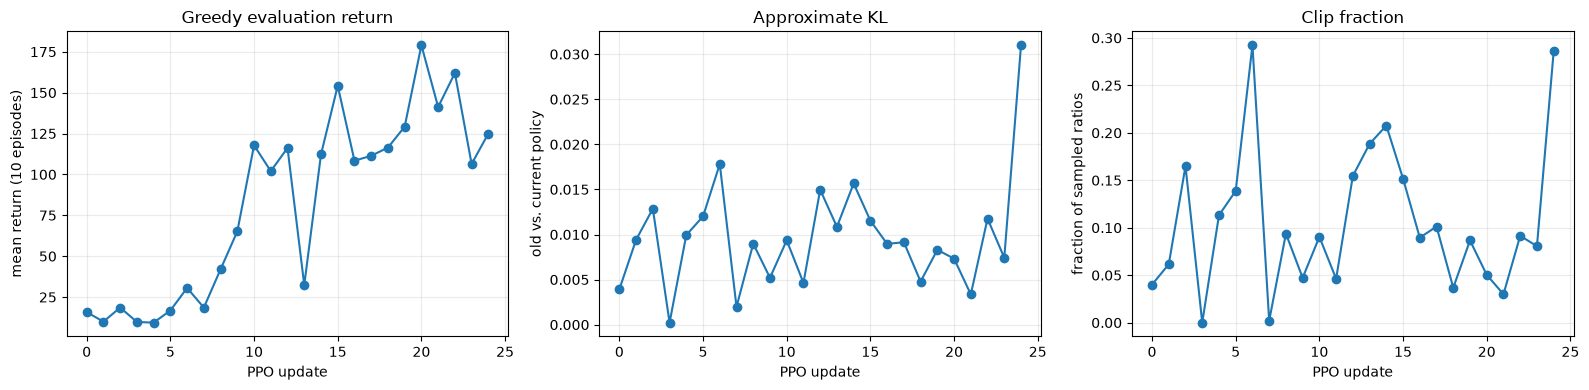

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(ppo_history["eval_return"], marker="o")
axes[0].set(title="Greedy evaluation return", xlabel="PPO update", ylabel="mean return (10 episodes)")
axes[1].plot(ppo_history["approx_kl"], marker="o")
axes[1].set(title="Approximate KL", xlabel="PPO update", ylabel="old vs. current policy")
axes[2].plot(ppo_history["clip_fraction"], marker="o")
axes[2].set(title="Clip fraction", xlabel="PPO update", ylabel="fraction of sampled ratios")
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Task 3 — Continuous-control PPO on Pendulum

This task uses PPO for a genuinely continuous-control problem: balancing and swinging up Gymnasium's `Pendulum-v1`.

`Pendulum-v1` has a three-dimensional observation and one continuous action in `[-2, 2]`, representing torque. At each time step the agent chooses both the direction and magnitude of the torque. 

We compare clipped PPO with the ordinary, un-clipped importance-weighted surrogate. Both variants use the same environment, network, rollout length, optimizer, and seeds, so the comparison isolates the effect of clipping while learning a continuous policy.


## Continuous actor and PPO implementation

The actor outputs the mean of a Gaussian distribution and learns its log standard deviation. A raw Gaussian sample must be squashed through `tanh`, then rescaled from `[-1, 1]` to the environment action range `[-2, 2]`.

### Student tasks — continuous action policy

Complete two focused methods in the code cell below:

1. `_distribution_and_value()`: use the shared representation to define both a Gaussian policy and a state-value prediction. Remember that a standard deviation must be positive.
2. `_squash_and_scale()`: first bound an unrestricted sample, then map the bounded interval onto Pendulum's action limits.

All remaining PPO code is provided, including action sampling, inverse action transformation, and the corrected log-probability calculation.


In [ ]:
import collections

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal


def set_task3_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


TASK3_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Task 3 device: {TASK3_DEVICE}")


class PendulumActorCritic(nn.Module):
    """Gaussian actor and value critic for one-dimensional continuous actions."""

    def __init__(self, observation_space, action_space):
        super().__init__()
        observation_size = int(np.prod(observation_space.shape))
        action_size = int(np.prod(action_space.shape))

        self.shared = nn.Sequential(
            nn.Linear(observation_size, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
        )
        self.actor_mean = nn.Linear(64, action_size)
        self.actor_log_std = nn.Parameter(torch.full((action_size,), -0.5))
        self.critic = nn.Linear(64, 1)

        action_low = torch.as_tensor(action_space.low, dtype=torch.float32)
        action_high = torch.as_tensor(action_space.high, dtype=torch.float32)
        self.register_buffer("action_scale", (action_high - action_low) / 2.0)
        self.register_buffer("action_bias", (action_high + action_low) / 2.0)

    def get_value(self, observations):
        return self.critic(self.shared(observations)).squeeze(-1)

    def _distribution_and_value(self, observations):
        """Build the state-conditioned Gaussian policy and critic prediction."""
        # TODO: Use self.shared(observations) to obtain features. From those
        # features, construct the action mean, positive standard deviation,
        # Normal distribution, and critic value.
        #
        # features = ...
        # mean = ...
        # standard_deviation = ... (Have to be positive)
        # distribution = ...
        # values = ...
        # return distribution, values
        raise NotImplementedError("Implement the Gaussian distribution and critic value.")

    def _squash_and_scale(self, raw_actions):
        """Map unbounded Gaussian actions to Pendulum's valid torque range."""
        # TODO: squash raw_actions with tanh, then rescale them with
        # self.action_scale and self.action_bias. Return both tensors as
        # (squashed_actions, actions).
        raise NotImplementedError("Implement the bounded continuous-action transform.")

    def get_action_and_value(self, observations, actions=None):
        """Sample a continuous action or evaluate a supplied action under the policy."""
        distribution, values = self._distribution_and_value(observations)
        values = values.squeeze(-1)
        if actions is None:
            raw_actions = distribution.rsample()
            squashed_actions, actions = self._squash_and_scale(raw_actions)
        else:
            squashed_actions = ((actions - self.action_bias) / self.action_scale).clamp(
                -0.999999, 0.999999
            )
            raw_actions = torch.atanh(squashed_actions)

        log_det_jacobian = torch.log(
            self.action_scale * (1 - squashed_actions.pow(2)) + 1e-6
        )
        log_probability = (
            distribution.log_prob(raw_actions) - log_det_jacobian
        ).sum(dim=-1)
        entropy = distribution.entropy().sum(dim=-1)
        return actions, log_probability, entropy, values

    def deterministic_action(self, observations):
        features = self.shared(observations)
        _, actions = self._squash_and_scale(self.actor_mean(features))
        return actions


# Auto-save the completed continuous-policy implementation when this cell runs.
save_current_cell_code(
    "E8_T3_PPO_Function_Implementation.txt",
    start_marker="class PendulumActorCritic",
    end_marker="# Auto-save",
)


## Rollout collection and PPO update

The rollout stores actions and log-probabilities from the policy that generated the data. During the update, those stored values remain fixed while the current policy is optimized for several epochs.
You don't need to change anything in this cell.


In [ ]:
def compute_gae(rewards, values, dones, last_value, gamma=0.9, gae_lambda=0.95):
    advantages = torch.zeros_like(rewards)
    gae = 0.0

    for t in reversed(range(len(rewards))):
        next_value = last_value if t == len(rewards) - 1 else values[t + 1]
        non_terminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * non_terminal - values[t]
        gae = delta + gamma * gae_lambda * non_terminal * gae
        advantages[t] = gae

    return advantages, advantages + values


def collect_pendulum_rollout(
    env,
    model,
    rollout_steps,
    device,
    observation=None,
    episode_return=0.0,
    seed=None,
    reward_scale=0.1,
    gamma=0.99,
):
    # Continue the current episode across PPO updates. Resetting at every
    # update discards part of an episode and makes the training curve noisier.
    if observation is None:
        observation, _ = env.reset(seed=seed)
    observations, actions, log_probs = [], [], []
    rewards, dones, values = [], [], []
    completed_returns = []
    model.eval()

    for _ in range(rollout_steps):
        observation_tensor = torch.as_tensor(
            observation, dtype=torch.float32, device=device
        ).unsqueeze(0)
        with torch.no_grad():
            action, log_prob, _, value = model.get_action_and_value(observation_tensor)

        environment_action = action.squeeze(0).cpu().numpy()
        next_observation, reward, terminated, truncated, _ = env.step(environment_action)
        done = terminated or truncated

        observations.append(observation_tensor.squeeze(0).cpu())
        actions.append(action.squeeze(0).cpu())
        log_probs.append(log_prob.squeeze(0).cpu())
        # Scale rewards used by the critic/GAE while reporting raw returns.
        # Pendulum rewards are much larger than CartPole rewards, and scaling
        # keeps value-function targets in a numerically convenient range.
        rewards.append(torch.tensor(reward * reward_scale, dtype=torch.float32))
        dones.append(torch.tensor(float(done), dtype=torch.float32))
        values.append(value.squeeze(0).cpu())

        episode_return += reward
        observation = next_observation
        if done:
            completed_returns.append(episode_return)
            observation, _ = env.reset()
            episode_return = 0.0

    with torch.no_grad():
        last_observation = torch.as_tensor(
            observation, dtype=torch.float32, device=device
        ).unsqueeze(0)
        last_value = model.get_value(last_observation).squeeze(0).cpu()

    rewards = torch.stack(rewards)
    values = torch.stack(values)
    dones = torch.stack(dones)
    advantages, returns = compute_gae(
        rewards, values, dones, last_value, gamma=gamma
    )

    return {
        "observations": torch.stack(observations),
        "actions": torch.stack(actions),
        "old_log_probs": torch.stack(log_probs),
        "advantages": advantages,
        "returns": returns,
        "completed_returns": completed_returns,
        "next_observation": observation,
        "unfinished_episode_return": episode_return,
    }


def ppo_update(
    model,
    optimizer,
    batch,
    device,
    clip_epsilon=0.2,
    use_clipping=True,
    update_epochs=10,
    minibatch_size=256,
    value_coef=0.5,
    entropy_coef=0.0,
    target_kl=0.02,
):
    observations = batch["observations"].to(device)
    actions = batch["actions"].to(device)
    old_log_probs = batch["old_log_probs"].to(device)
    returns = batch["returns"].to(device)
    advantages = batch["advantages"].to(device)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    metrics = collections.defaultdict(list)

    model.train()
    for _ in range(update_epochs):
        epoch_kls = []
        permutation = torch.randperm(len(observations), device=device)
        for indices in permutation.split(minibatch_size):
            _, new_log_probs, entropy, new_values = model.get_action_and_value(
                observations[indices], actions[indices]
            )
            log_ratio = new_log_probs - old_log_probs[indices]
            ratio = log_ratio.exp()
            surrogate = ratio * advantages[indices]
            clipped_surrogate = torch.clamp(
                ratio, 1 - clip_epsilon, 1 + clip_epsilon
            ) * advantages[indices]
            policy_objective = (
                torch.minimum(surrogate, clipped_surrogate)
                if use_clipping
                else surrogate
            )
            policy_loss = -policy_objective.mean()
            value_loss = 0.5 * (returns[indices] - new_values).pow(2).mean()
            entropy_bonus = entropy.mean()
            loss = policy_loss + value_coef * value_loss - entropy_coef * entropy_bonus

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

            approximate_kl = ((ratio - 1.0) - log_ratio).mean().item()
            metrics["approx_kl"].append(approximate_kl)
            epoch_kls.append(approximate_kl)
            metrics["clip_fraction"].append(
                ((ratio - 1.0).abs() > clip_epsilon).float().mean().item()
            )

        # Clipping limits the objective but does not impose a hard trust region.
        # Stop early if repeated minibatch epochs move the policy too far.
        if target_kl is not None and np.mean(epoch_kls) > target_kl:
            break

    return {name: float(np.mean(values)) for name, values in metrics.items()}


def evaluate_pendulum(model, device, episodes=10, seed=10_000):
    env = gym.make("Pendulum-v1")
    returns = []
    model.eval()

    for episode in range(episodes):
        observation, _ = env.reset(seed=seed + episode)
        total_return = 0.0

        while True:
            observation_tensor = torch.as_tensor(
                observation, dtype=torch.float32, device=device
            ).unsqueeze(0)
            with torch.no_grad():
                action = model.deterministic_action(observation_tensor)
            observation, reward, terminated, truncated, _ = env.step(
                action.squeeze(0).cpu().numpy()
            )
            total_return += reward
            if terminated or truncated:
                break

        returns.append(total_return)

    env.close()
    return float(np.mean(returns))


def train_pendulum_ppo(
    seed,
    use_clipping,
    updates,
    rollout_steps,
    evaluation_episodes,
    learning_rate,
    gamma,
    clip_epsilon,
    evaluation_interval=5,
    verbose=True,
):
    set_task3_seed(seed)
    env = gym.make("Pendulum-v1")
    model = PendulumActorCritic(env.observation_space, env.action_space).to(TASK3_DEVICE)
    initial_learning_rate = learning_rate
    optimizer = optim.Adam(
        model.parameters(), lr=initial_learning_rate, eps=1e-5
    )
    history = collections.defaultdict(list)
    observation = None
    unfinished_episode_return = 0.0

    for update in range(updates):
        # Anneal the learning rate to make late-stage policy updates gentler.
        current_learning_rate = initial_learning_rate * (1.0 - update / updates)
        optimizer.param_groups[0]["lr"] = current_learning_rate
        batch = collect_pendulum_rollout(
            env,
            model,
            rollout_steps,
            TASK3_DEVICE,
            observation=observation,
            episode_return=unfinished_episode_return,
            seed=seed,
            gamma=gamma,
        )
        observation = batch["next_observation"]
        unfinished_episode_return = batch["unfinished_episode_return"]
        metrics = ppo_update(
            model,
            optimizer,
            batch,
            TASK3_DEVICE,
            clip_epsilon=clip_epsilon,
            use_clipping=use_clipping,
        )
        # Each value is the cumulative reward from one completed training episode.
        # Keeping these separately lets us plot learning against episodes rather
        # than using PPO updates as a proxy for training progress.
        history["train_episode_return"].extend(batch["completed_returns"])
        history["approx_kl"].append(metrics["approx_kl"])
        history["clip_fraction"].append(metrics["clip_fraction"])

        should_evaluate = (
            update == 0
            or (update + 1) % evaluation_interval == 0
            or update == updates - 1
        )
        if should_evaluate:
            evaluation_return = evaluate_pendulum(
                model,
                TASK3_DEVICE,
                episodes=evaluation_episodes,
                # Reuse the same initial states at every checkpoint so changes
                # in this curve reflect the policy rather than evaluation luck.
                seed=20_000 + 100 * seed,
            )
            history["eval_update"].append(update + 1)
            history["eval_return"].append(evaluation_return)

        if verbose and should_evaluate:
            print(
                f"update {update + 1:02d}/{updates}: "
                f"evaluation return={evaluation_return:8.1f}, "
                f"KL={metrics['approx_kl']:.4f}"
            )

    env.close()
    return model, history


## Experiment protocol

Train both objectives with seeds `0`, `1`, and `2`. Pendulum rewards are negative; higher returns (closer to zero) are better. The tuned configuration uses a shorter discount horizon ($\gamma=0.9$), reward scaling for value learning, a linearly annealed learning rate starting at $10^{-3}$, and early stopping when approximate KL exceeds `0.02`. These settings make the small continuous-control example learn reliably while retaining the clipped-versus-unclipped ablation. Use the full configuration for the final comparison; you may temporarily reduce the number of updates while debugging.

| Objective | PPO updates | Rollout steps | PPO epochs | Evaluation episodes |
|---|---:|---:|---:|---:|
| Clipped PPO ($\epsilon=0.2$) | 60 | 1024 | up to 10 | 10 every 5 updates |
| No clipping | 60 | 1024 | up to 10 | 10 every 5 updates |


In [ ]:
PENDULUM_UPDATES = 60
PENDULUM_ROLLOUT_STEPS = 1024
PENDULUM_EVALUATION_EPISODES = 10
LEARNING_RATE = 1e-3
GAMMA = 0.90
EPSILON = 0.2

PENDULUM_EVALUATION_INTERVAL = 5
TASK3_SEEDS = [0, 1, 2]
TASK3_VARIANTS = {
    "Clipped PPO": True,
    "No clipping": False,
}

task3_runs = collections.defaultdict(list)
for variant_label, use_clipping in TASK3_VARIANTS.items():
    for seed in TASK3_SEEDS:
        print(f"Training Pendulum | {variant_label} | seed={seed}")
        model, history = train_pendulum_ppo(
            seed=seed,
            use_clipping=use_clipping,
            updates=PENDULUM_UPDATES,
            rollout_steps=PENDULUM_ROLLOUT_STEPS,
            evaluation_episodes=PENDULUM_EVALUATION_EPISODES,
            learning_rate=LEARNING_RATE,
            gamma=GAMMA,
            clip_epsilon=EPSILON,
            evaluation_interval=PENDULUM_EVALUATION_INTERVAL,
            verbose=False,
        )
        final_return = evaluate_pendulum(
            model,
            TASK3_DEVICE,
            episodes=30,
            seed=50_000 + 100 * seed,
        )
        task3_runs[variant_label].append(
            {"seed": seed, "history": history, "final_return": final_return}
        )
        print(f"  final 30-episode return: {final_return:.1f}")


## Results

The first plot shows deterministic evaluation return against PPO updates. Evaluation uses the same initial states at each checkpoint, so its trend is directly comparable over training. The second plot shows **training episodic return**: the cumulative reward collected in each completed training episode, plotted against the number of completed episodes. Curves are averaged over seeds and smoothed with a 25-episode moving average; shading shows one standard deviation across seeds. This gives a direct clipped-versus-unclipped comparison on the requested episode axis. The final plot shows policy-movement diagnostics. In the no-clipping condition, `clip_fraction` is still reported as the fraction of samples that would have been outside the nominal `[0.8, 1.2]` range.


In [ ]:
fig, axis = plt.subplots(figsize=(8, 4.5))
for variant_label, runs in task3_runs.items():
    curves = np.array([run["history"]["eval_return"] for run in runs])
    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    updates = np.asarray(runs[0]["history"]["eval_update"])
    axis.plot(updates, mean_curve, label=variant_label)
    axis.fill_between(updates, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

axis.set(
    title="Pendulum learning curves",
    xlabel="PPO update",
    ylabel="mean deterministic evaluation return",
)
axis.grid(alpha=0.25)
axis.legend()
caption = (
    "Caption (replace this placeholder with 2–3 sentences): "
    "Briefly explain your understanding of the graph and its main findings."
)
fig.text(0.5, 0.02, caption, ha="center", va="bottom", wrap=True, fontsize=9)
plt.tight_layout(rect=(0, 0.16, 1, 1))
output_path = submission_path("E8_T3_Learning_Curve.png")
fig.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Saved: {output_path}")
plt.show()

# Cumulative reward (return) per completed training episode.
# Truncate to the shortest seed run before aggregating, which also makes this
# robust if the environment yields slightly different episode counts.
smoothing_window = 25
fig, axis = plt.subplots(figsize=(8, 4.5))
for variant_label, runs in task3_runs.items():
    episode_returns = [
        np.asarray(run["history"]["train_episode_return"], dtype=float)
        for run in runs
    ]
    common_length = min(map(len, episode_returns))
    episode_returns = np.stack(
        [returns[:common_length] for returns in episode_returns]
    )
    window = min(smoothing_window, common_length)
    kernel = np.ones(window) / window
    smoothed_returns = np.stack([
        np.convolve(returns, kernel, mode="valid")
        for returns in episode_returns
    ])
    mean_return = smoothed_returns.mean(axis=0)
    std_return = smoothed_returns.std(axis=0)
    episodes = np.arange(window, common_length + 1)
    axis.plot(episodes, mean_return, label=variant_label)
    axis.fill_between(
        episodes, mean_return - std_return, mean_return + std_return, alpha=0.2
    )

axis.set(
    title="Pendulum training return by episode",
    xlabel="Completed training episode",
    ylabel="Cumulative return per episode (25-episode moving average)",
)
axis.grid(alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
for variant_label, runs in task3_runs.items():
    updates = np.arange(1, len(runs[0]["history"]["approx_kl"]) + 1)
    mean_kl = np.array([run["history"]["approx_kl"] for run in runs]).mean(axis=0)
    mean_outside = np.array(
        [run["history"]["clip_fraction"] for run in runs]
    ).mean(axis=0)
    axes[0].plot(updates, mean_kl, label=variant_label)
    axes[1].plot(updates, mean_outside, label=variant_label)

axes[0].set(title="Policy-movement diagnostics", ylabel="approximate KL")
axes[1].set(xlabel="PPO update", ylabel="ratio outside [0.8, 1.2]")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
caption = (
    "Caption (replace this placeholder with 2–3 sentences): "
    "Briefly explain your understanding of the graph and its main findings."
)
fig.text(0.5, 0.02, caption, ha="center", va="bottom", wrap=True, fontsize=9)
plt.tight_layout(rect=(0, 0.10, 1, 1))
output_path = submission_path("E8_T3_Policy_Movement_Diagnostics.png")
fig.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Saved: {output_path}")
plt.show()


## Submission

The table reports each seed and the mean across seeds. Higher Pendulum return is better because the reward is negative.

After entering your CID in the CID cell below the title, running the relevant code cells automatically saves the implemented code and required figures in `./submission`.

Submit one executed notebook containing:

1. Your **implemented functions**: _distribution_and_value() and _squash_and_scale().

    File name: `CID_E8_T3_PPO_Function_Implementation.txt`

2. The **learning curve** and **policy-movement diagnostics**. In each graph, replace the placeholder caption with **2–3 sentences** that briefly explain your understanding and findings, focusing on the differences between clipped and un-clipped PPO.

    File name: `CID_E8_T3_Learning_Curve.png`

    File name: `CID_E8_T3_Policy_Movement_Diagnostics.png`

3. The per-seed and aggregate **result tables**.

    File name: `CID_E8_T3_Results_Tables.png`

4. An **evidence-based** comparison of clipped versus un-clipped PPO. Refer to both return and KL / ratio-movement results, and explain whether clipping improved stability for these runs.

    File name: `CID_E8_T3_Clipping_Comparison.txt`


In [ ]:
task3_rows = []
for variant_label, runs in task3_runs.items():
    for run in runs:
        history = run["history"]
        task3_rows.append(
            {
                "variant": variant_label,
                "seed": run["seed"],
                "final_30_episode_return": run["final_return"],
                "late_approx_kl": float(np.mean(history["approx_kl"][-10:])),
                "late_ratio_outside_range": float(
                    np.mean(history["clip_fraction"][-10:])
                ),
            }
        )

task3_seed_table = pd.DataFrame(task3_rows)
task3_summary_table = (
    task3_seed_table.groupby("variant")
    .agg(
        return_mean=("final_30_episode_return", "mean"),
        return_std=("final_30_episode_return", "std"),
        approx_kl_mean=("late_approx_kl", "mean"),
        outside_range_mean=("late_ratio_outside_range", "mean"),
    )
    .round(3)
)
rounded_seed_table = task3_seed_table.round(3)
ipythondisplay.display(rounded_seed_table)
ipythondisplay.display(task3_summary_table)

# Render both result tables into one submission-ready image.
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5))
for axis, table_data, title in [
    (axes[0], rounded_seed_table, "Per-seed results"),
    (axes[1], task3_summary_table.reset_index(), "Aggregate results"),
]:
    axis.axis("off")
    table = axis.table(cellText=table_data.values,
                       colLabels=table_data.columns,
                       cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.35)
    axis.set_title(title, pad=12)

fig.suptitle("Pendulum PPO results", fontsize=14)
fig.tight_layout()
output_path = submission_path("E8_T3_Results_Tables.png")
fig.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Saved: {output_path}")
plt.show()
